In [ ]:
!pip install torch torchvision transformers pillow

Step 2 — Import libraries

In [ ]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

Step 3 — Load CLIP model

In [ ]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Step 4 — Load image

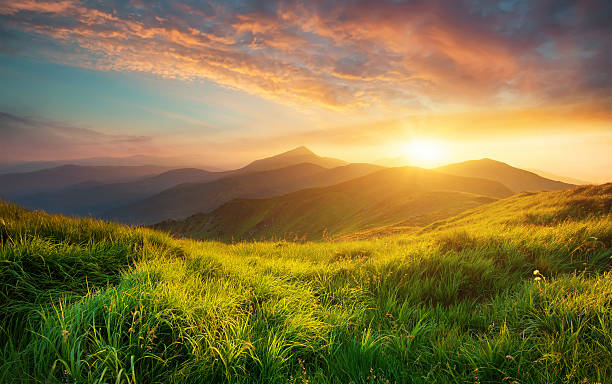

In [ ]:
image = Image.open("/content/nature img.jpg")
image

Step 5 — Define candidate captions

In [ ]:
captions = [
"a dog",
"a cat",
"a person",
"a man",
"a woman",
"a laptop",
"a computer",
"a car",
"a bike",
"a street",
"a building",
"a landscape",
"a mountain",
"a river",
"a phone",
"a classroom",
"a student",
"a teacher",
"a food",
"a plate of food"
]

Step 6 — Encode image + text

In [ ]:
inputs = processor(
    text=captions,
    images=image,
    return_tensors="pt",
    padding=True
)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)

Step 7 — Get best caption

In [ ]:
best_idx = probs.argmax().item()
print("Predicted Caption:", captions[best_idx])

Predicted Caption: a beautiful landscape


Step 8 — Full Code (Final)

In [ ]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

image = Image.open("/content/nature img.jpg")

captions = [
    "a photo of a dog",
    "a photo of a cat",
    "a person riding a bike",
    "a group of people",
    "a car on the road",
    "a beautiful landscape",
    "a person using laptop",
    "food on a plate"
]

inputs = processor(
    text=captions,
    images=image,
    return_tensors="pt",
    padding=True
)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)

best_idx = probs.argmax().item()

print("Predicted Caption:", captions[best_idx])

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Predicted Caption: a beautiful landscape
